# 🏏 IPL Spin Model — Prediction Validation

**Purpose:** Load new match JSON files → run saved model → compare predicted vs actual runs.

**Requires (from training notebook):**
```
model_runs.pkl
model_wicket.pkl  
encoder_spin.pkl
encoder_phase.pkl
batter_features.csv
venue_features.csv
form_features.csv
```

**Workflow:**
```
New JSON files  →  Parse deliveries  →  Filter spin  →  Load model  →  Predict  →  Compare vs actual
```

---

## 📦 Step 1 — Imports

In [1]:
import os
import json
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Imports done')

✅ Imports done


---
## ⚙️ Step 2 — Configuration
**Only edit this cell.**

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDIT THESE PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Option A: point to a folder of Cricsheet JSON files (original) ──────────
NEW_MATCHES_FOLDER = '../json/ipl_match'   # ← change to your JSON folder

# ── Option B: use cricsheet_balls_parsed.csv directly (recommended) ──────────
# Set USE_CSV = True and point CRICSHEET_CSV to your cleaned CSV.
# When USE_CSV = True, NEW_MATCHES_FOLDER is ignored.
USE_CSV        = True
CRICSHEET_CSV  = 'cricsheet_balls_parsed.csv'   # ← must be in MODEL_FOLDER

# Folder where your saved model .pkl and .csv files are
MODEL_FOLDER = '.'    # ← '.' means same folder as this notebook

# Minimum balls a batter must have faced vs spin (for meaningful comparison)
MIN_BALLS = 5

# Spin bowling types to include
SPIN_TYPES = [
    'right-arm offbreak',
    'legbreak',
    'legbreak googly',
    'slow left-arm orthodox',
    'left-arm wrist-spin'
]

# ── Venue cleaning map (keeps venue names consistent with venue_features.csv) ─
VENUE_MAP = {
    'Wankhede Stadium, Mumbai'                                             : 'Wankhede Stadium',
    'Eden Gardens, Kolkata'                                                : 'Eden Gardens',
    'M Chinnaswamy Stadium, Bengaluru'                                     : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                                                : 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk'                                      : 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'                             : 'MA Chidambaram Stadium',
    'Arun Jaitley Stadium, Delhi'                                          : 'Arun Jaitley Stadium',
    'Rajiv Gandhi International Stadium, Uppal'                            : 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'                 : 'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association Stadium, Mohali'                           : 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'                 : 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh'    : 'Punjab Cricket Association IS Bindra Stadium',
    'Sawai Mansingh Stadium, Jaipur'                                       : 'Sawai Mansingh Stadium',
    'Narendra Modi Stadium, Ahmedabad'                                     : 'Narendra Modi Stadium',
    'Sardar Patel Stadium, Motera'                                         : 'Narendra Modi Stadium',
    'Dr DY Patil Sports Academy, Mumbai'                                   : 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai'                                            : 'Brabourne Stadium',
    'Maharashtra Cricket Association Stadium, Pune'                        : 'Maharashtra Cricket Association Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala'             : 'Himachal Pradesh Cricket Association Stadium',
    'Barsapara Cricket Stadium, Guwahati'                                  : 'Barsapara Cricket Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur'   : 'New Chandigarh Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh': 'New Chandigarh Stadium',
}

print(f'USE_CSV            : {USE_CSV}')
print(f'Cricsheet CSV      : {CRICSHEET_CSV}')
print(f'Model folder       : {MODEL_FOLDER}')

USE_CSV            : True
Cricsheet CSV      : cricsheet_balls_parsed.csv
Model folder       : .


---
## 💾 Step 3 — Load Saved Model

In [3]:
def load_model_files(folder):
    """Load all saved model artifacts. Raises clear error if any file is missing."""
    required = {
        'runs_model'    : 'model_runs.pkl',
        'wkt_model'     : 'model_wicket.pkl',
        'le_spin'       : 'encoder_spin.pkl',
        'le_phase'      : 'encoder_phase.pkl',
        'batter_feats'  : 'batter_features.csv',
        'venue_feats'   : 'venue_features.csv',
        'form_feats'    : 'form_features.csv',
    }

    # Check all files exist before loading anything
    missing = []
    for key, filename in required.items():
        path = os.path.join(folder, filename)
        if not os.path.exists(path):
            missing.append(filename)

    if missing:
        raise FileNotFoundError(
            f"Missing model files: {missing}\n"
            f"Run the training notebook (IPL_Spin_Prediction_Model_v3.ipynb) first."
        )

    # Load everything
    artifacts = {}
    for key, filename in required.items():
        path = os.path.join(folder, filename)
        if filename.endswith('.pkl'):
            artifacts[key] = joblib.load(path)
        else:
            artifacts[key] = pd.read_csv(path)
        print(f'  ✅ Loaded {filename}')

    return artifacts


arts = load_model_files(MODEL_FOLDER)

runs_model   = arts['runs_model']
wkt_model    = arts['wkt_model']
le_spin      = arts['le_spin']
le_phase     = arts['le_phase']
batter_feats = arts['batter_feats']
venue_feats  = arts['venue_feats']
form_feats   = arts['form_feats']

# Build spin bowler lookup from batter_feats (names that appeared as bowlers in training)
# Note: spin_map is encoded in the encoder classes
print(f'\nKnown spin types  : {list(le_spin.classes_)}')
print(f'Known phases      : {list(le_phase.classes_)}')
print(f'Batters in model  : {len(batter_feats)}')

  ✅ Loaded model_runs.pkl
  ✅ Loaded model_wicket.pkl
  ✅ Loaded encoder_spin.pkl
  ✅ Loaded encoder_phase.pkl
  ✅ Loaded batter_features.csv
  ✅ Loaded venue_features.csv
  ✅ Loaded form_features.csv

Known spin types  : ['left-arm wrist-spin', 'legbreak', 'legbreak googly', 'right-arm offbreak', 'slow left-arm orthodox']
Known phases      : ['death', 'middle', 'powerplay']
Batters in model  : 534


---
## 📂 Step 4 — Parse New Match JSON Files

In [4]:
def parse_match(filepath):
    """
    Parse one Cricsheet JSON match file.
    Returns DataFrame with one row per delivery.
    """
    match_id = os.path.splitext(os.path.basename(filepath))[0]

    try:
        with open(filepath, encoding='utf-8') as f:
            m = json.load(f)
    except Exception as e:
        print(f'  ⚠ Could not read {filepath}: {e}')
        return pd.DataFrame()

    info   = m.get('info', {})
    teams  = info.get('teams', [])
    venue  = info.get('venue', '')
    season = str(info.get('season', ''))
    winner = info.get('outcome', {}).get('winner',
             info.get('outcome', {}).get('result', 'No result'))
    winner_by = info.get('outcome', {}).get('by', {})
    margin = list(winner_by.values())[0] if winner_by else None
    margin_type = list(winner_by.keys())[0] if winner_by else None

    rows = []
    for inn_idx, inn in enumerate(m.get('innings', [])):
        batting_team = inn.get('team', '')
        for od in inn.get('overs', []):
            over_num = od.get('over', -1)
            for ball_num, ball in enumerate(od.get('deliveries', [])):
                extras   = ball.get('extras', {})
                runs     = ball.get('runs', {})
                wickets  = ball.get('wickets', [])
                is_wide  = int('wides'   in extras)
                is_noball= int('noballs' in extras)
                rows.append({
                    # Identifiers
                    'match_id'    : match_id,
                    'innings'     : inn_idx + 1,
                    'over'        : over_num,
                    'ball_number' : ball_num + 1,
                    # Players
                    'batter'      : ball.get('batter', ''),
                    'bowler'      : ball.get('bowler', ''),
                    # Actual outcomes  ← what we compare predictions against
                    'actual_runs' : runs.get('batter', 0),
                    'total_runs'  : runs.get('total', 0),
                    'is_wicket'   : int(bool(wickets)),
                    'wicket_kind' : wickets[0].get('kind', '') if wickets else '',
                    # Extras
                    'is_wide'     : is_wide,
                    'is_noball'   : is_noball,
                    # Match context
                    'venue'       : venue,
                    'season'      : season,
                    'batting_team': batting_team,
                    # Match result
                    'winner'      : winner,
                    'margin'      : margin,
                    'margin_type' : margin_type,
                    'team1'       : teams[0] if teams else '',
                    'team2'       : teams[1] if len(teams) > 1 else '',
                })
    return pd.DataFrame(rows)


def load_all_matches(folder, skip_files=None):
    """Load all Cricsheet JSON files from a folder."""
    if skip_files is None:
        skip_files = {'teams_info.json'}

    files = [
        f for f in sorted(glob.glob(os.path.join(folder, '*.json')))
        if os.path.basename(f) not in skip_files
    ]

    if not files:
        raise FileNotFoundError(
            f"No JSON files found in '{folder}'.\n"
            f"Put your new match JSON files there and re-run."
        )

    print(f'Found {len(files)} match files — parsing...')
    dfs = []
    for i, fp in enumerate(files):
        df = parse_match(fp)
        if not df.empty:
            dfs.append(df)
        if (i+1) % 50 == 0 or (i+1) == len(files):
            print(f'  {i+1}/{len(files)} files parsed')

    combined = pd.concat(dfs, ignore_index=True)
    return combined


if USE_CSV:
    # ── Load directly from cricsheet_balls_parsed.csv ─────────────────────────
    _csv_path = os.path.join(MODEL_FOLDER, CRICSHEET_CSV)
    _raw_csv  = pd.read_csv(_csv_path, low_memory=False)

    # Apply venue cleaning
    _raw_csv['venue'] = _raw_csv['venue'].replace(VENUE_MAP)

    # Rename to match expected column names used later in this notebook
    raw = _raw_csv.rename(columns={
        'ball_in_over': 'ball_number',
        'runs_batter' : 'actual_runs',
        'is_wicket'   : 'is_wicket',
    })

    # Derive is_wide / is_noball from columns
    if 'is_wide' not in raw.columns:
        raw['is_wide']   = (raw.get('wides',  pd.Series(0, index=raw.index)) > 0).astype(int)
    if 'is_noball' not in raw.columns:
        raw['is_noball'] = (raw.get('noballs', pd.Series(0, index=raw.index)) > 0).astype(int)

    # Ensure wicket_kind column exists
    if 'wicket_kind' not in raw.columns and 'kind' in raw.columns:
        raw['wicket_kind'] = raw['kind']
    elif 'wicket_kind' not in raw.columns:
        raw['wicket_kind'] = ''

    # Add team1/team2 placeholders if not present
    for col in ['team1', 'team2', 'winner']:
        if col not in raw.columns:
            raw[col] = ''

    print(f'Loaded from CSV         : {len(raw):,} rows')
    print(f'Matches                 : {raw["match_id"].nunique()}')
    print(f'Seasons                 : {sorted(raw["season"].dropna().unique())}')
    print(f'Venues (after cleaning) : {raw["venue"].nunique()}')
else:
    # ── Original JSON path ────────────────────────────────────────────────────
    raw = load_all_matches(NEW_MATCHES_FOLDER)
    raw['venue'] = raw['venue'].replace(VENUE_MAP)  # clean venues from JSON too
    print(f'\nTotal deliveries parsed : {len(raw):,}')
    print(f'Matches                 : {raw["match_id"].nunique()}')
    print(f'Seasons                 : {sorted(raw["season"].unique())}')
    print(f'Venues (after cleaning) : {raw["venue"].nunique()}')

Loaded from CSV         : 278,205 rows
Matches                 : 1169
Seasons                 : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']
Venues (after cleaning) : 40


---
## 🌀 Step 5 — Filter Spin Deliveries

In [5]:
def prepare_spin_deliveries(df, spin_types, le_spin, le_phase,
                            batter_feats, venue_feats, form_feats):
    """
    From raw delivery data:
    1. Remove wides and no-balls (illegal deliveries)
    2. Filter to spin bowlers only
    3. Add phase, encoded features, batter history, venue, form
    Returns DataFrame ready for model prediction.
    """
    # Remove illegal deliveries
    legal = df[(df['is_wide'] == 0) & (df['is_noball'] == 0)].copy()

    # Build spin map from players who appear in training encoder
    # We use the batter_feats to get their historical spin type
    # But first we need to know which bowlers are spinners
    # Load players CSV if available, otherwise use only known spin bowlers
    players_path = os.path.join(MODEL_FOLDER, '2026_players_details.csv')
    if os.path.exists(players_path):
        players = pd.read_csv(players_path)
        players['longBowlingStyles'] = players['longBowlingStyles'].replace('Na', np.nan)
        spin_map = {
            r['Name']: r['longBowlingStyles']
            for _, r in players.iterrows()
            if r['longBowlingStyles'] in spin_types
        }
    else:
        # Fallback: only include bowlers whose type is in the encoder classes
        print('  ⚠ 2026_players_details.csv not found — spin bowler list may be incomplete')
        spin_map = {}

    spin = legal[legal['bowler'].isin(spin_map)].copy()
    spin['spin_type'] = spin['bowler'].map(spin_map)

    if spin.empty:
        raise ValueError('No spin deliveries found — check bowler names match your players CSV')

    # Phase
    spin['phase'] = pd.cut(
        spin['over'],
        bins=[-1, 5, 14, 19],
        labels=['powerplay', 'middle', 'death']
    )

    # Encode spin type and phase — produce plain int, not Categorical
    # Converting to str first avoids pandas Categorical issues with LightGBM
    spin['spin_type_enc'] = spin['spin_type'].apply(
        lambda x: int(le_spin.transform([x])[0]) if x in le_spin.classes_ else -1
    ).astype(int)
    spin['phase_enc'] = spin['phase'].astype(str).apply(
        lambda x: int(le_phase.transform([x])[0]) if x in le_phase.classes_ else 1
    ).astype(int)

    # Ball-level derived features (using original lowercase names before rename)
    spin['ball_in_over_norm'] = spin['ball_number'] / 6
    spin['is_last_ball']      = (spin['ball_number'] == 6).astype(int)
    spin['over_x_ball']       = spin['over'] * spin['ball_number']
    spin['is_death_last']     = ((spin['over'] >= 17) & (spin['ball_number'] >= 5)).astype(int)

    # Merge batter historical features
    BATTER_COLS = ['Batter','sr','avg','dot_pct','boundary_pct',
                   'six_pct','wkt_rate','rotation_pct','cluster']
    spin = spin.merge(
        batter_feats[BATTER_COLS].rename(columns={'Batter':'batter'}).fillna(0),
        on='batter', how='left'
    )

    # Merge venue features
    spin = spin.merge(venue_feats, on='venue', how='left')
    global_wkt = venue_feats['venue_spin_wkt_rate'].mean()
    global_eco = venue_feats['venue_spin_economy'].mean()
    spin['venue_spin_wkt_rate'] = spin['venue_spin_wkt_rate'].fillna(global_wkt)
    spin['venue_spin_economy']  = spin['venue_spin_economy'].fillna(global_eco)

    # Merge form features
    spin = spin.merge(
        form_feats.rename(columns={'Batter':'batter'}),
        on='batter', how='left'
    )
    spin['form_sr_last5'] = spin['form_sr_last5'].fillna(spin['sr'])

    # Fill missing batter features with dataset mean
    numeric_cols = ['sr','avg','dot_pct','boundary_pct','six_pct',
                    'wkt_rate','rotation_pct','cluster']
    for col in numeric_cols:
        if col in spin.columns:
            spin[col] = spin[col].fillna(batter_feats[col].mean() if col in batter_feats else 0)

    return spin, spin_map


spin_df, spin_map = prepare_spin_deliveries(
    raw, SPIN_TYPES, le_spin, le_phase,
    batter_feats, venue_feats, form_feats
)

print(f'Spin deliveries in new matches : {len(spin_df):,}')
print(f'Unique batters vs spin          : {spin_df["batter"].nunique()}')
print(f'Spin bowlers in these matches   : {spin_df["bowler"].nunique()}')
print(f'\nSpin type breakdown:')
print(spin_df['spin_type'].value_counts())

Spin deliveries in new matches : 58,243
Unique batters vs spin          : 534
Spin bowlers in these matches   : 69

Spin type breakdown:
spin_type
right-arm offbreak        16801
legbreak googly           14872
slow left-arm orthodox    13434
legbreak                  10280
left-arm wrist-spin        2856
Name: count, dtype: int64


In [6]:
# ── Build X_new feature matrix and pred_df from spin_df ──────────────────────
# This cell was missing — it bridges prepare_spin_deliveries() → model.predict()

FEATURES = [
    'Overs', 'BallNumber', 'Innings',
    'spin_type_enc', 'phase_enc',
    'ball_in_over_norm', 'is_last_ball', 'over_x_ball', 'is_death_last',
    'sr', 'avg', 'dot_pct', 'boundary_pct',
    'six_pct', 'wkt_rate', 'rotation_pct',
    'cluster',
    'venue_spin_wkt_rate', 'venue_spin_economy',
    'form_sr_last5',
]

# Rename delivery-level columns to match training feature names
spin_df = spin_df.rename(columns={
    'innings'     : 'Innings',
    'over'        : 'Overs',
    'ball_number' : 'BallNumber',
})

# Build feature matrix — only rows where all features are present
X_new = spin_df[FEATURES].copy().fillna(0)

# Build pred_df: carry along ground-truth columns needed for accuracy metrics
pred_df = spin_df[[
    'match_id', 'batter', 'bowler', 'spin_type', 'phase',
    'actual_runs', 'is_wicket', 'venue', 'batting_team',
    'winner', 'team1', 'team2',
]].copy().reset_index(drop=True)

X_new = X_new.reset_index(drop=True)

print(f'Feature matrix shape : {X_new.shape}')
print(f'pred_df rows         : {len(pred_df)}')
print(f'Features             : {list(X_new.columns)}')


Feature matrix shape : (58243, 20)
pred_df rows         : 58243
Features             : ['Overs', 'BallNumber', 'Innings', 'spin_type_enc', 'phase_enc', 'ball_in_over_norm', 'is_last_ball', 'over_x_ball', 'is_death_last', 'sr', 'avg', 'dot_pct', 'boundary_pct', 'six_pct', 'wkt_rate', 'rotation_pct', 'cluster', 'venue_spin_wkt_rate', 'venue_spin_economy', 'form_sr_last5']


---
## 🔮 Step 6 — Run Predictions

In [7]:
# Use only what the model was actually trained on
MODEL_FEATURES = list(runs_model.feature_names_in_)
print("Model expects:", MODEL_FEATURES)

X_new_model = X_new[MODEL_FEATURES].copy()

# Run both models
pred_df['predicted_runs']    = runs_model.predict(X_new_model).clip(0)
pred_df['dismissal_prob']    = wkt_model.predict_proba(X_new_model)[:, 1]
pred_df['expected_runs']     = pred_df['predicted_runs'] * (1 - pred_df['dismissal_prob'])
pred_df['prediction_error']  = pred_df['predicted_runs'] - pred_df['actual_runs']

print(f'Predictions generated for {len(pred_df):,} deliveries')
print(f'\nSample predictions vs actuals:')
print(pred_df[['batter','bowler','spin_type','actual_runs',
               'predicted_runs','dismissal_prob']].head(10).round(3).to_string())

Model expects: ['Overs', 'BallNumber', 'Innings', 'spin_type_enc', 'phase_enc', 'ball_in_over_norm', 'is_last_ball', 'over_x_ball', 'is_death_last', 'sr', 'avg', 'dot_pct', 'boundary_pct', 'six_pct', 'wkt_rate', 'rotation_pct', 'cluster', 'venue_spin_wkt_rate', 'venue_spin_economy', 'form_sr_last5']
Predictions generated for 58,243 deliveries

Sample predictions vs actuals:
         batter     bowler        spin_type  actual_runs  predicted_runs  dismissal_prob
0  MC Henriques  YS Chahal  legbreak googly            0           1.032           0.034
1  MC Henriques  YS Chahal  legbreak googly            1           1.032           0.034
2      S Dhawan  YS Chahal  legbreak googly            0           1.142           0.031
3      S Dhawan  YS Chahal  legbreak googly            1           1.146           0.031
4  MC Henriques  YS Chahal  legbreak googly            1           1.019           0.035
5      S Dhawan  YS Chahal  legbreak googly            1           1.142           0.030


---
## 📊 Step 7 — Accuracy Metrics
### How correct were the predictions?

In [8]:
def compute_metrics(pred_df):
    """Compute all prediction accuracy metrics."""
    mae  = mean_absolute_error(pred_df['actual_runs'], pred_df['predicted_runs'])
    rmse = np.sqrt(mean_squared_error(pred_df['actual_runs'], pred_df['predicted_runs']))
    
    # % of predictions within ±1 run
    within_1 = (pred_df['prediction_error'].abs() <= 1).mean() * 100

    # Wicket model AUC (only if there are actual wickets)
    if pred_df['is_wicket'].sum() > 10:
        auc = roc_auc_score(pred_df['is_wicket'], pred_df['dismissal_prob'])
    else:
        auc = None

    # Bias: are we over- or under-predicting?
    bias = pred_df['prediction_error'].mean()  # positive = over-predicting

    # Actual vs predicted mean SR
    actual_sr    = pred_df['actual_runs'].mean() * 100
    predicted_sr = pred_df['predicted_runs'].mean() * 100

    return {
        'Deliveries evaluated' : len(pred_df),
        'MAE (runs/ball)'      : round(mae, 4),
        'RMSE (runs/ball)'     : round(rmse, 4),
        'Within ±1 run (%)'    : round(within_1, 1),
        'Bias (mean error)'    : round(bias, 4),
        'Actual mean SR'       : round(actual_sr, 1),
        'Predicted mean SR'    : round(predicted_sr, 1),
        'Wicket AUC'           : round(auc, 4) if auc else 'N/A (too few wickets)',
    }


metrics = compute_metrics(pred_df)

print('=' * 45)
print('  OVERALL MODEL ACCURACY — NEW MATCHES')
print('=' * 45)
for k, v in metrics.items():
    print(f'  {k:<28}: {v}')
print('=' * 45)
print()
print('  Interpretation:')
mae_val = metrics['MAE (runs/ball)']
if mae_val < 1.0:
    print('  ✅ Excellent — MAE < 1.0 run/ball')
elif mae_val < 1.2:
    print('  ✅ Good — MAE between 1.0 and 1.2')
elif mae_val < 1.5:
    print('  ⚠ Fair — MAE between 1.2 and 1.5')
else:
    print('  ❌ Poor — MAE > 1.5, model may not generalise well to these matches')

bias_val = metrics['Bias (mean error)']
if abs(bias_val) < 0.05:
    print('  ✅ Unbiased — mean error close to 0')
elif bias_val > 0:
    print(f'  ⚠ Over-predicting runs by {bias_val:.3f} per ball on average')
else:
    print(f'  ⚠ Under-predicting runs by {abs(bias_val):.3f} per ball on average')

  OVERALL MODEL ACCURACY — NEW MATCHES
  Deliveries evaluated        : 58243
  MAE (runs/ball)             : 1.0917
  RMSE (runs/ball)            : 1.5749
  Within ±1 run (%)           : 55.6
  Bias (mean error)           : 0.0005
  Actual mean SR              : 126.4
  Predicted mean SR           : 126.4
  Wicket AUC                  : 0.657

  Interpretation:
  ✅ Good — MAE between 1.0 and 1.2
  ✅ Unbiased — mean error close to 0


In [9]:
# Breakdown by spin type
print('Accuracy by Spin Type:')
spin_type_metrics = pred_df.groupby('spin_type').apply(
    lambda g: pd.Series({
        'deliveries'       : len(g),
        'actual_sr'        : round(g['actual_runs'].mean() * 100, 1),
        'predicted_sr'     : round(g['predicted_runs'].mean() * 100, 1),
        'MAE'              : round(mean_absolute_error(g['actual_runs'], g['predicted_runs']), 4),
        'bias'             : round((g['predicted_runs'] - g['actual_runs']).mean(), 4),
    })
).reset_index()
print(spin_type_metrics.to_string(index=False))

print('\nAccuracy by Phase:')
phase_metrics = pred_df.groupby('phase').apply(
    lambda g: pd.Series({
        'deliveries'   : len(g),
        'actual_sr'    : round(g['actual_runs'].mean() * 100, 1),
        'predicted_sr' : round(g['predicted_runs'].mean() * 100, 1),
        'MAE'          : round(mean_absolute_error(g['actual_runs'], g['predicted_runs']), 4),
    })
).reset_index()
print(phase_metrics.to_string(index=False))

Accuracy by Spin Type:
             spin_type  deliveries  actual_sr  predicted_sr    MAE    bias
   left-arm wrist-spin      2856.0      131.0         131.5 1.1269  0.0052
              legbreak     10280.0      129.9         121.7 1.0881 -0.0819
       legbreak googly     14872.0      127.5         129.0 1.1361  0.0153
    right-arm offbreak     16801.0      122.2         125.9 1.0680  0.0370
slow left-arm orthodox     13434.0      126.7         126.8 1.0673  0.0006

Accuracy by Phase:
    phase  deliveries  actual_sr  predicted_sr    MAE
powerplay      8699.0      126.5         122.7 1.2206
   middle     41926.0      123.5         124.8 1.0350
    death      7618.0      141.9         139.5 1.2565


---
## 🏏 Step 8 — Per-Batter Prediction Accuracy

In [10]:
# Aggregate predictions and actuals per batter per match
batter_match = pred_df.groupby(['match_id', 'batter', 'batting_team']).agg(
    actual_runs     = ('actual_runs',    'sum'),
    predicted_runs  = ('predicted_runs', 'sum'),
    expected_runs   = ('expected_runs',  'sum'),
    balls_faced     = ('actual_runs',    'count'),
    actual_wickets  = ('is_wicket',      'sum'),
    avg_dismiss_prob= ('dismissal_prob', 'mean'),
).reset_index()

# Only include batters who faced enough spin balls
batter_match = batter_match[batter_match['balls_faced'] >= MIN_BALLS].copy()

# Accuracy metrics per batter-match
batter_match['run_error']       = batter_match['predicted_runs'] - batter_match['actual_runs']
batter_match['abs_error']       = batter_match['run_error'].abs()
batter_match['actual_sr']       = batter_match['actual_runs']    / batter_match['balls_faced'] * 100
batter_match['predicted_sr']    = batter_match['predicted_runs'] / batter_match['balls_faced'] * 100

# Verdict: was the prediction correct?
# Within 15% of actual = correct (for example 20 predicted, 17-23 actual = correct)
batter_match['correct_prediction'] = (batter_match['abs_error'] / batter_match['balls_faced'].clip(1) <= 0.5)

print(f'Batter-match pairs evaluated: {len(batter_match)}')
print(f'Correct predictions (±0.5 runs/ball): {batter_match["correct_prediction"].mean()*100:.1f}%')
print()
batter_match[[
    'match_id','batter','balls_faced',
    'actual_runs','predicted_runs','expected_runs',
    'run_error','abs_error','actual_sr','predicted_sr','correct_prediction'
]].sort_values('abs_error').head(20).round(2)

Batter-match pairs evaluated: 4667
Correct predictions (±0.5 runs/ball): 65.9%



,match_id,batter,balls_faced,actual_runs,predicted_runs,expected_runs,run_error,abs_error,actual_sr,predicted_sr,correct_prediction
3571,1136620,SR Watson,10,14,14.00,12.99,0.00,0.00,140.00,140.01,True
5878,1312200,SV Samson,6,8,8.00,7.71,-0.00,0.00,133.33,133.32,True
5098,1254105,S Dhawan,9,10,10.00,9.64,-0.00,0.00,111.11,111.10,True
7812,1473493,Shubman Gill,7,10,10.00,9.73,-0.00,0.00,142.86,142.83,True
5192,1254114,RV Uthappa,14,16,16.00,15.12,-0.00,0.00,114.29,114.26,True
4574,1216541,Ishan Kishan,9,11,11.00,10.60,-0.00,0.00,122.22,122.18,True
644,501254,Mandeep Singh,6,8,7.99,7.05,-0.01,0.01,133.33,133.25,True
1901,829759,MC Henriques,12,14,13.99,13.42,-0.01,0.01,116.67,116.61,True
6806,1422139,BR Sharath,5,2,2.01,1.66,0.01,0.01,40.00,40.15,True
2190,980929,S Dhawan,10,12,12.01,11.46,0.01,0.01,120.00,120.09,True


In [11]:
# Career-level accuracy: how well does model predict each batter overall?
batter_overall = batter_match.groupby('batter').agg(
    matches          = ('match_id',       'nunique'),
    total_actual     = ('actual_runs',    'sum'),
    total_predicted  = ('predicted_runs', 'sum'),
    total_expected   = ('expected_runs',  'sum'),
    total_balls      = ('balls_faced',    'sum'),
    mean_abs_error   = ('abs_error',      'mean'),
    correct_pct      = ('correct_prediction', lambda x: x.mean()*100),
).reset_index()

batter_overall['actual_sr']    = batter_overall['total_actual']    / batter_overall['total_balls'] * 100
batter_overall['predicted_sr'] = batter_overall['total_predicted'] / batter_overall['total_balls'] * 100
batter_overall['sr_diff']      = (batter_overall['predicted_sr'] - batter_overall['actual_sr']).round(1)

print('Per-Batter Model Accuracy (sorted by most balls faced):')
print()
batter_overall.sort_values('total_balls', ascending=False).round(2).to_string(index=False)

Per-Batter Model Accuracy (sorted by most balls faced):



'             batter  matches  total_actual  total_predicted  total_expected  total_balls  mean_abs_error  correct_pct  actual_sr  predicted_sr  sr_diff\n            V Kohli      121          2028          1952.06         1902.97         1630            3.67        79.34     124.42        119.76     -4.7\n          RG Sharma       97          1257          1221.09         1160.16         1061            3.63        72.16     118.47        115.09     -3.4\n           KL Rahul       73          1302          1272.28         1240.91         1020            4.90        72.60     127.65        124.73     -2.9\n           S Dhawan       80          1232          1136.88         1095.85          982            3.96        73.75     125.46        115.77     -9.7\n          DA Warner       77          1413          1383.41         1343.52          977            4.58        68.83     144.63        141.60     -3.0\n           SA Yadav       72          1261          1235.71         1204.46      

In [12]:
# ── Build match_summary for the per-match visualisation ──────────────────────
# This cell was missing — it bridges batter_match → match_summary used in Plot 2

match_summary = pred_df.groupby(
    ['match_id', 'batting_team', 'winner', 'team1', 'team2']
).agg(
    balls          = ('actual_runs',    'count'),
    actual_runs    = ('actual_runs',    'sum'),
    predicted_runs = ('predicted_runs', 'sum'),
    wickets        = ('is_wicket',      'sum'),
).reset_index()

# Sort chronologically / by match_id
match_summary = match_summary.sort_values('match_id').reset_index(drop=True)

print(f'match_summary rows : {len(match_summary)}')
print(f'Matches covered    : {match_summary["match_id"].nunique()}')
print()
print(match_summary[['match_id','batting_team','balls','actual_runs','predicted_runs']].to_string(index=False))


match_summary rows : 1750
Matches covered    : 1021

 match_id                batting_team  balls  actual_runs  predicted_runs
   335983         Chennai Super Kings      6           19        7.669286
   335987            Rajasthan Royals     12           27       18.441758
   335991              Mumbai Indians     24           15       19.971015
   335995            Delhi Daredevils     24           27       25.028077
   335999             Deccan Chargers     24           28       23.367077
   336003       Kolkata Knight Riders      6           16        7.825485
   336006 Royal Challengers Bangalore     24           20       22.116088
   336013         Chennai Super Kings     18           35       18.786336
   336015            Rajasthan Royals     17           24       22.110136
   336016 Royal Challengers Bangalore     24           28       25.700498
   336017       Kolkata Knight Riders     18           13       17.088571
   336019            Rajasthan Royals     24           35  

---
## 📈 Step 9 — Visualisations

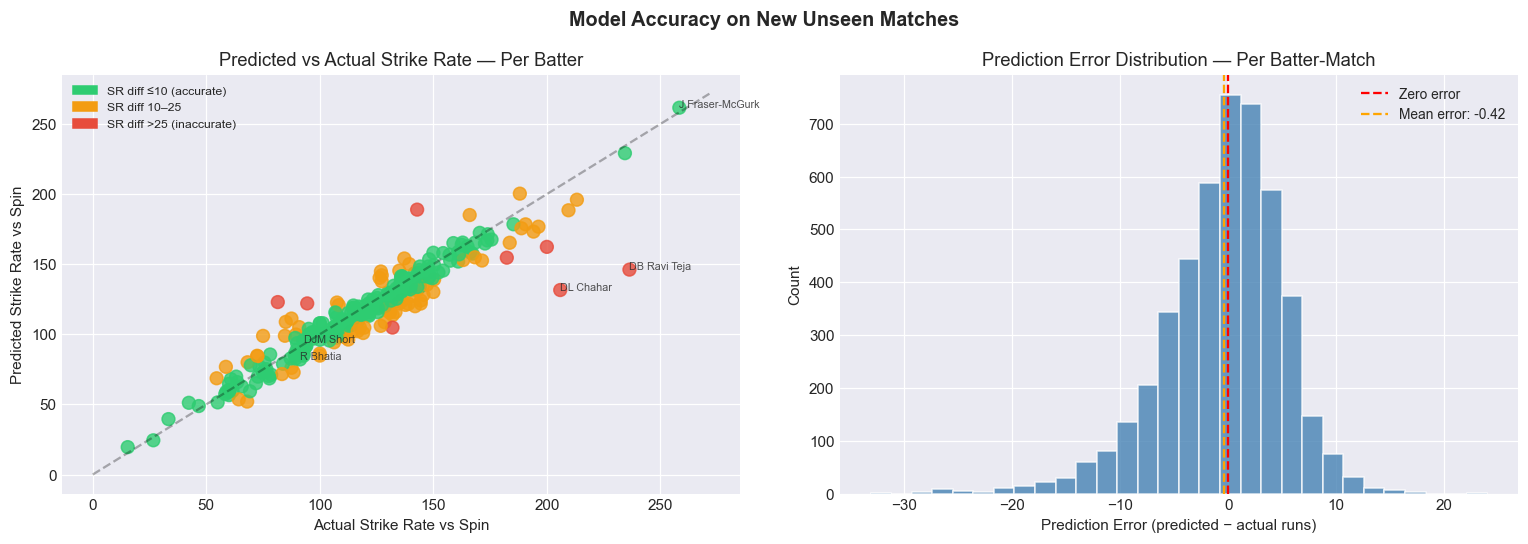

In [13]:
# ── Plot 1: Predicted vs Actual runs per batter ──────────────────
plot_df = batter_overall[batter_overall['total_balls'] >= 10].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted SR vs actual SR
colors = ['#2ecc71' if abs(d) <= 10 else '#f39c12' if abs(d) <= 25 else '#e74c3c'
          for d in plot_df['sr_diff']]

axes[0].scatter(plot_df['actual_sr'], plot_df['predicted_sr'],
                c=colors, s=70, alpha=0.8)

# Perfect prediction line
lim = max(plot_df['actual_sr'].max(), plot_df['predicted_sr'].max()) + 10
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Perfect prediction')
axes[0].set_xlabel('Actual Strike Rate vs Spin')
axes[0].set_ylabel('Predicted Strike Rate vs Spin')
axes[0].set_title('Predicted vs Actual Strike Rate — Per Batter')
axes[0].legend(fontsize=9)

# Annotate biggest errors
for _, row in plot_df.nlargest(5, 'mean_abs_error').iterrows():
    axes[0].annotate(row['batter'],
                     (row['actual_sr'], row['predicted_sr']),
                     fontsize=7, alpha=0.8)

# Add legend patches
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2ecc71', label='SR diff ≤10 (accurate)'),
    Patch(color='#f39c12', label='SR diff 10–25'),
    Patch(color='#e74c3c', label='SR diff >25 (inaccurate)'),
], fontsize=8)

# Bar: Prediction efrror distribution
axes[1].hist(batter_match['run_error'], bins=30,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Zero error')
axes[1].axvline(batter_match['run_error'].mean(), color='orange',
                linestyle='--', label=f'Mean error: {batter_match["run_error"].mean():.2f}')
axes[1].set_xlabel('Prediction Error (predicted − actual runs)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Error Distribution — Per Batter-Match')
axes[1].legend(fontsize=9)

plt.suptitle('Model Accuracy on New Unseen Matches', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

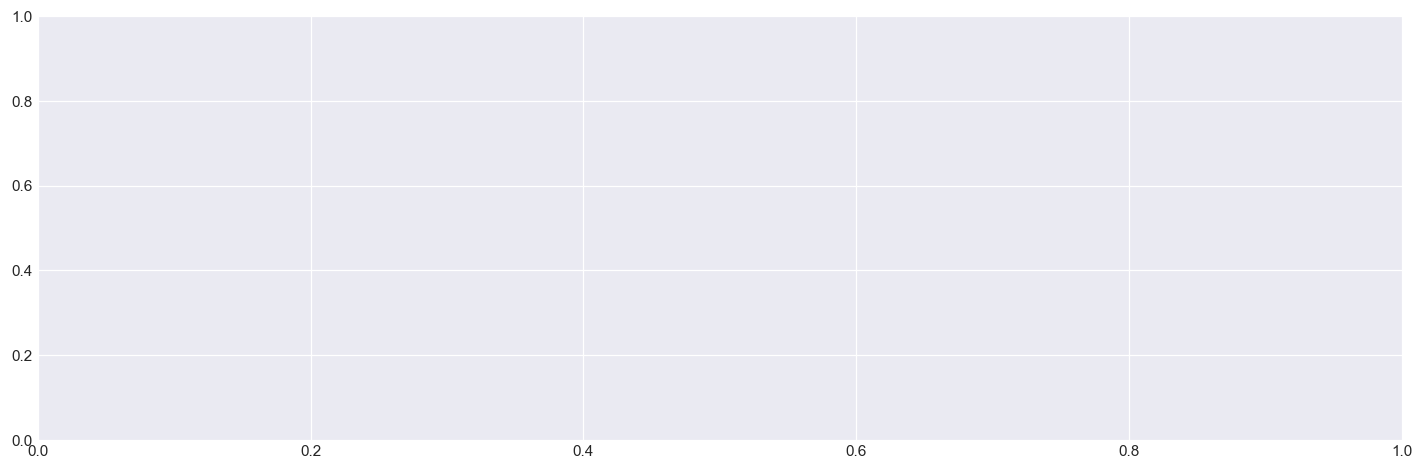

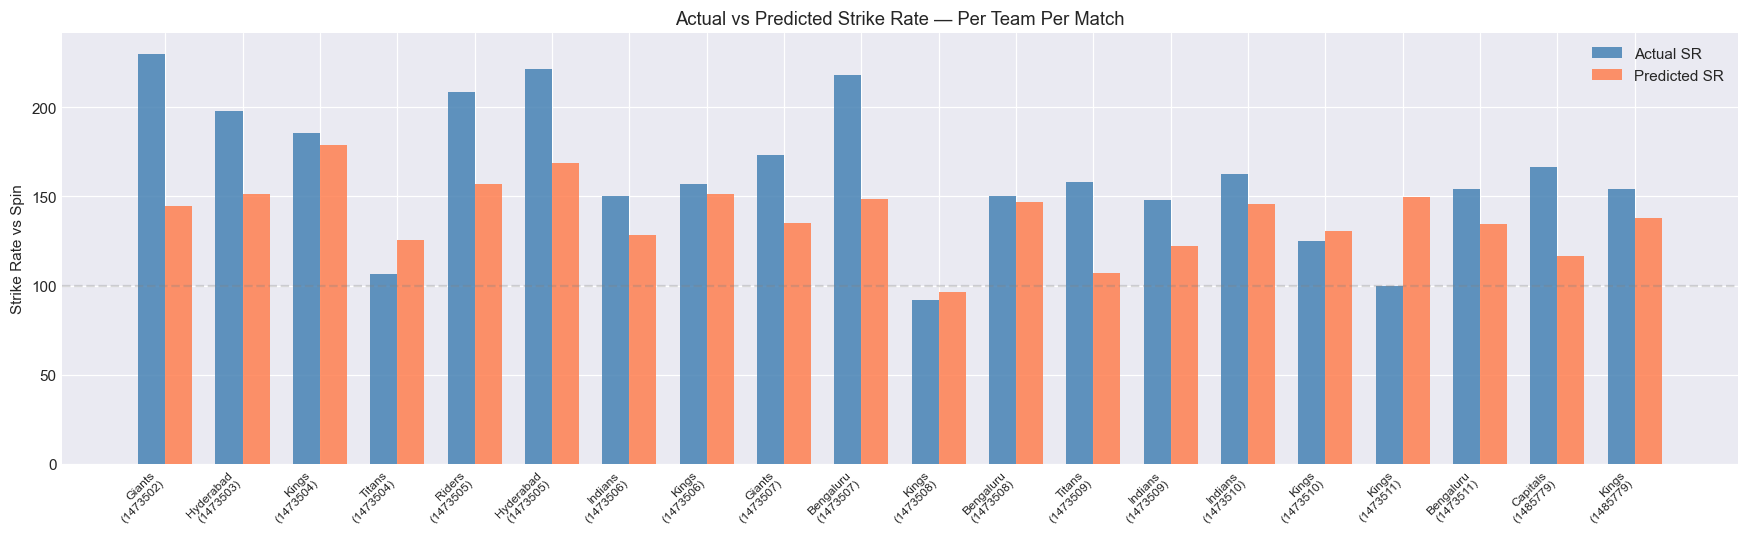

In [14]:
# ── Plot 2: Actual vs Predicted SR per match (innings view) ──────
match_summary = match_summary.tail(20).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(16, 5))
x      = range(len(match_summary))

match_summary['actual_sr']    = match_summary['actual_runs']    / match_summary['balls'] * 100
match_summary['predicted_sr'] = match_summary['predicted_runs'] / match_summary['balls'] * 100
match_summary['label']        = match_summary['batting_team'].str.split().str[-1]  # short name

fig, ax = plt.subplots(figsize=(max(12, len(match_summary)*0.8), 5))
x      = range(len(match_summary))
width  = 0.35

ax.bar([i - width/2 for i in x], match_summary['actual_sr'],
       width=width, label='Actual SR',    color='steelblue', alpha=0.85)
ax.bar([i + width/2 for i in x], match_summary['predicted_sr'],
       width=width, label='Predicted SR', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['label']}\n({r['match_id']})" for _, r in match_summary.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Strike Rate vs Spin')
ax.set_title('Actual vs Predicted Strike Rate — Per Team Per Match')
ax.legend()
ax.axhline(100, color='grey', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

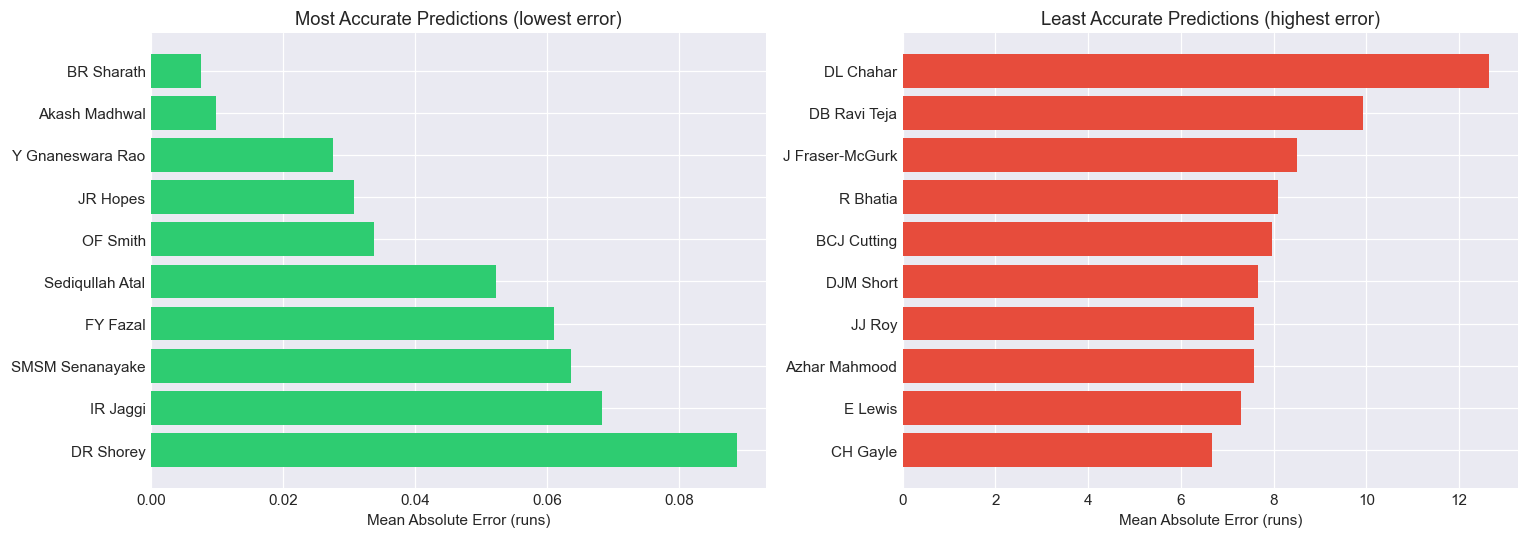

In [15]:
# ── Plot 3: Top 10 most accurate vs least accurate batter predictions
if len(batter_overall) >= 5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top10_accurate = batter_overall.nsmallest(10, 'mean_abs_error')
    top10_inaccurate = batter_overall.nlargest(10, 'mean_abs_error')

    axes[0].barh(top10_accurate['batter'], top10_accurate['mean_abs_error'],
                 color='#2ecc71')
    axes[0].set_title('Most Accurate Predictions (lowest error)')
    axes[0].set_xlabel('Mean Absolute Error (runs)')
    axes[0].invert_yaxis()

    axes[1].barh(top10_inaccurate['batter'], top10_inaccurate['mean_abs_error'],
                 color='#e74c3c')
    axes[1].set_title('Least Accurate Predictions (highest error)')
    axes[1].set_xlabel('Mean Absolute Error (runs)')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

---
## 🏆 Step 10 — Match Result Summary

In [16]:
# Show each match: actual result + how model predicted each team would perform vs spin
print('MATCH-BY-MATCH SUMMARY')
print('=' * 75)

for mid in sorted(match_summary['match_id'].unique()):
    mdf = match_summary[match_summary['match_id'] == mid]
    winner = mdf['winner'].iloc[0]
    team1  = mdf['team1'].iloc[0] if 'team1' in mdf.columns else '?'
    team2  = mdf['team2'].iloc[0] if 'team2' in mdf.columns else '?'

    print(f'\n  Match {mid}: {team1} vs {team2}')
    print(f'  Result : {winner} won')
    print(f'  {'Team':<30} {'Balls vs Spin':>14} {'Actual SR':>10} {'Pred SR':>10} {'Diff':>8}')
    print(f'  {"-"*30} {"-"*14} {"-"*10} {"-"*10} {"-"*8}')

    for team in mdf['batting_team'].unique():
        tdf = mdf[mdf['batting_team'] == team]
        balls       = len(tdf)
        actual_sr   = tdf['actual_runs'].mean() * 100
        pred_sr     = tdf['predicted_runs'].mean() * 100
        diff        = pred_sr - actual_sr
        flag = '✅' if abs(diff) <= 15 else '⚠'
        print(f'  {team:<30} {balls:>14} {actual_sr:>10.1f} {pred_sr:>10.1f} {diff:>+7.1f} {flag}')

print('\n' + '=' * 75)

MATCH-BY-MATCH SUMMARY

  Match 1473502:  vs 
  Result : Lucknow Super Giants won
  Team                            Balls vs Spin  Actual SR    Pred SR     Diff
  ------------------------------ -------------- ---------- ---------- --------
  Lucknow Super Giants                        1     6900.0     4336.8 -2563.2 ⚠

  Match 1473503:  vs 
  Result : Sunrisers Hyderabad won
  Team                            Balls vs Spin  Actual SR    Pred SR     Diff
  ------------------------------ -------------- ---------- ---------- --------
  Sunrisers Hyderabad                         1     8300.0     6349.9 -1950.1 ⚠

  Match 1473504:  vs 
  Result : Chennai Super Kings won
  Team                            Balls vs Spin  Actual SR    Pred SR     Diff
  ------------------------------ -------------- ---------- ---------- --------
  Chennai Super Kings                         1     7800.0     7515.4  -284.6 ⚠
  Gujarat Titans                              1     5100.0     6021.6  +921.6 ⚠

  Match

---
## 💾 Step 11 — Export Results

In [17]:
# Export all results to CSV
batter_match.to_csv('validation_batter_match.csv', index=False)
batter_overall.to_csv('validation_batter_overall.csv', index=False)
match_summary.to_csv('validation_match_summary.csv',   index=False)

# Summary metrics to text file
with open('validation_metrics.txt', 'w') as f:
    f.write('IPL SPIN MODEL — VALIDATION RESULTS\n')
    f.write('=' * 45 + '\n')
    for k, v in metrics.items():
        f.write(f'{k:<28}: {v}\n')

print('Exported:')
print('  validation_batter_match.csv   — per batter per match predictions')
print('  validation_batter_overall.csv — per batter overall accuracy')
print('  validation_match_summary.csv  — per match summary')
print('  validation_metrics.txt        — overall accuracy numbers')

Exported:
  validation_batter_match.csv   — per batter per match predictions
  validation_batter_overall.csv — per batter overall accuracy
  validation_match_summary.csv  — per match summary
  validation_metrics.txt        — overall accuracy numbers


---
## 📋 Quick Reference

### How to use this notebook
1. Put new unseen match JSON files into `NEW_MATCHES_FOLDER`
2. Make sure `model_runs.pkl`, `model_wicket.pkl`, etc. are in `MODEL_FOLDER`
3. Run all cells — results appear in Steps 7–10

### What each output means
| Metric | Meaning | Good value |
|---|---|---|
| MAE (runs/ball) | Average prediction error per delivery | < 1.1 |
| Within ±1 run % | % of balls predicted within 1 run | > 70% |
| Bias | Positive = over-predicting, negative = under | Close to 0 |
| Wicket AUC | Dismissal prediction quality | > 0.60 |
| SR diff | Predicted SR minus actual SR per batter | ±10 = good |

### Folder structure needed
```
csv/
  IPL_Spin_Validation.ipynb         ← this file
  model_runs.pkl
  model_wicket.pkl
  encoder_spin.pkl
  encoder_phase.pkl
  batter_features.csv
  venue_features.csv
  form_features.csv
  2024_players_details.csv

json/
  ipl_match_new/                    ← put new JSON files here
    1234567.json
    1234568.json
    ...
```